In [3]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
#pandas para leer el archivo CSV y extraer únicamente las columnas numéricas
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 2.- Regresión lineal con múltiples variables


## Paso 1: Cargar con Pandas y extraer matrices de NumPy

In [5]:
# 1. Cargar el dataset con Pandas
df = pd.read_csv('diabetes_risk_prediction_dataset.csv')

# 2. Filtrar únicamente las columnas numéricas
df_numerico = df.select_dtypes(include=[np.number])

# 3. Eliminar la columna Patient_ID si existe
if 'Patient_ID' in df_numerico.columns:
    df_numerico = df_numerico.drop(columns=['Patient_ID'])

# 4. Eliminar filas que contengan valores nulos (nan)
df_numerico = df_numerico.dropna()

# 5. Separar la variable objetivo (y) de las características (X)
y_col = 'Diabetes_Risk_Score'

X = df_numerico.drop(columns=[y_col]).to_numpy()
y = df_numerico[y_col].to_numpy()

m = y.size
n = X.shape[1]

print(f"Número de muestras limpias (m): {m}")
print(f"Número de características numéricas (n): {n}\n")

print("Primeras 5 filas de X (sin NaNs):")
print(X[:5])
print("\nPrimeros 5 valores de y:")
print(y[:5])

Número de muestras limpias (m): 33689
Número de características numéricas (n): 20

Primeras 5 filas de X (sin NaNs):
[[ 32.  182.1  65.8  19.8  71.2  88.4  10.4 149.5  27.4  94.   61.  138.7
   40.1 152.3 250.8 119.    2.2 106.1   7.9   4.4]
 [ 42.  148.5 101.2  45.9 121.8 247.3  11.3 199.3  18.3 148.  100.  286.8
   35.6 110.4 287.9  59.    6.3  96.1   6.2   2.1]
 [ 87.  190.9  95.9  26.3  99.1  90.1   7.4 217.7  36.7 120.   63.  168.2
   61.9  63.4 308.8  58.    7.7  23.1   4.2   1.5]
 [ 27.  156.9 101.9  41.4  77.1  93.8  12.  153.5  22.3 190.   90.  281.5
   37.4  66.5 206.6 104.    4.7 131.2   9.9   1.6]
 [ 29.  153.3  86.3  36.7  77.1 142.2   5.  123.7  44.4 123.  119.  276.8
   54.6 121.9 385.5 112.    1.9  39.2   8.2   4.4]]

Primeros 5 valores de y:
[60 99 82 93 69]


## Paso 2: Normalización de Características y Columna de Unos

In [6]:
# 1. Definición de la función de normalización
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# 2. Llama a featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada (mu) para cada columna:')
print(mu)
print('\nDesviación estándar calculada (sigma):')
print(sigma)
print('\nPrimeras 5 filas de X_norm:')
print(X_norm[:5])

# 3. Añade el término de intersección a X (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print('\nDimensiones finales de la matriz X (filas, columnas):', X.shape)

Media calculada (mu) para cada columna:
[ 53.95971979 169.96791237  87.46979133  30.96007896 100.02420671
 159.51276084   8.4916679  142.60413191  23.52957939 140.16147704
  90.10593962 219.938894    57.38526522 134.91272819 229.30495711
  85.10216985   5.01626644  90.209466     6.5022589    2.99394758]

Desviación estándar calculada (sigma):
[21.09948134 14.46928116 24.5175793  10.32146097 23.10570914 51.94802478
  2.31157511 44.72690288 12.4129902  29.14646644 17.54691189 57.71751451
 18.67943095 49.14819232 98.37989391 20.38363423  2.87388093 52.01314324
  2.0271519   1.15187025]

Primeras 5 filas de X_norm:
[[-1.0407706   0.83847204 -0.8838471  -1.08124993 -1.24749284 -1.36892136
   0.82555487  0.15417719  0.31180405 -1.5837761  -1.65874997 -1.40752586
  -0.92536359  0.35377236  0.2184902   1.66299247 -0.97995237  0.30550997
   0.6895098   1.2206691 ]
 [-0.5668253  -1.48368894  0.56001486  1.44746185  0.94244211  1.68990524
   1.21489978  1.26760103 -0.42129892  0.26893562  0.56386

## Paso 3: Función de Costo, Descenso por el Gradiente y Gráfica

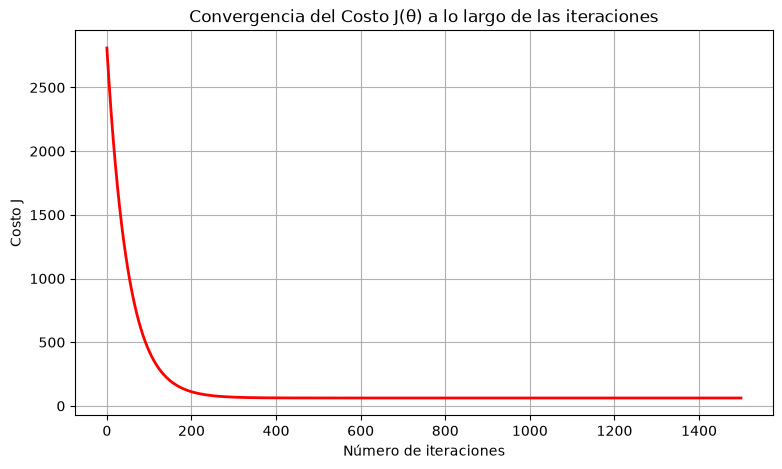

Costo inicial J(θ): 2809.7928
Costo final alcanzado J(θ): 61.9726

Parámetros Theta optimizados:
[ 7.40717235e+01  4.26826977e+00 -9.06126928e-01  2.00984384e+00
  1.41265306e+00 -5.19309580e-02  1.26922295e-01  4.89119838e+00
  7.15344810e+00 -5.26759300e-02  2.39303280e+00  1.59842851e+00
  1.88746405e+00 -1.78350185e-02 -3.87235234e-02 -7.31866952e-02
  2.37100966e-03 -5.74863135e-02  7.30518600e-02 -1.14824394e+00
 -2.66937809e-04]


In [7]:
# 1. Definición de la Función de Costo
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

# 2. Definición del Descenso por el Gradiente Vectorizado
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        # Actualización de theta mediante cálculo vectorial
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        # Guarda el costo en cada iteración para monitorear la convergencia
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

# 3. Configuración de Hiperparámetros y Entrenamiento
alpha = 0.01        # Tasa de aprendizaje
num_iters = 1500    # Número de iteraciones

# Inicializa theta en ceros con la dimensión correcta (21 parámetros)
theta_inicial = np.zeros(X.shape[1])

# Ejecuta el descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y, theta_inicial, alpha, num_iters)

# 4. Graficar la convergencia de la Función de Costo
pyplot.figure(figsize=(9, 5))
pyplot.plot(np.arange(len(J_history)), J_history, '-r', lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo J(θ) a lo largo de las iteraciones')
pyplot.grid(True)
pyplot.show()

# 5. Imprimir resultados
print(f'Costo inicial J(θ): {J_history[0]:.4f}')
print(f'Costo final alcanzado J(θ): {J_history[-1]:.4f}\n')
print('Parámetros Theta optimizados:')
print(theta)

## 1. INFERENCIA CON GRADIENTE DESCENDENTE


In [9]:
# 1. Creamos la matriz X_raw original para obtener datos no escalados
X_raw = df_numerico.drop(columns=['Diabetes_Risk_Score']).to_numpy()

# Tomamos el primer paciente como dato crudo sin normalizar (o podrías colocar valores manuales)
paciente_muestra = X_raw[0]

# 2. Normalizamos la muestra usando la mu y sigma guardadas del entrenamiento
paciente_norm = (paciente_muestra - mu) / sigma

# 3. Agregamos el 1 al inicio para x0
paciente_final = np.insert(paciente_norm, 0, 1)

# 4. Predicción mediante el producto punto con theta
prediccion_gradiente = np.dot(paciente_final, theta)

print("INFERENCIA (DESCENSO POR EL GRADIENTE)")
print(f"Predicción del puntaje de riesgo: {prediccion_gradiente:.2f}")
print(f"Valor real en el dataset: {y[0]:.2f}\n")

INFERENCIA (DESCENSO POR EL GRADIENTE)
Predicción del puntaje de riesgo: 60.76
Valor real en el dataset: 60.00



## 2. ECUACIÓN DE LA NORMAL

In [10]:
# Preparamos la matriz X con la columna de unos sin normalizar
X_normal_eq = np.concatenate([np.ones((m, 1)), X_raw], axis=1)

def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

# Calculamos theta con la fórmula analítica
theta_normal = normalEqn(X_normal_eq, y)

# Para predecir con Ecuación de la Normal NO se usa normalización
paciente_normal_eq = np.insert(paciente_muestra, 0, 1)
prediccion_normal = np.dot(paciente_normal_eq, theta_normal)

print("ECUACIÓN DE LA NORMAL")
print("Theta calculado mediante Ecuación de la Normal:")
print(theta_normal)
print(f"\nPredicción con Ecuación de la Normal: {prediccion_normal:.2f}")

ECUACIÓN DE LA NORMAL
Theta calculado mediante Ecuación de la Normal:
[ 9.98330045e+00  2.02134622e-01 -1.30037881e-01  1.47180681e-01
 -4.50826847e-02 -2.16537399e-03  2.41544505e-03  2.11624124e+00
  1.59924365e-01 -4.21088788e-03  8.21284732e-02  9.10274967e-02
  3.27243594e-02 -8.01234440e-04 -7.93345400e-04 -7.18634291e-04
  1.30223898e-04 -1.98453216e-02  1.41753350e-03 -5.65253714e-01
  8.87404735e-04]

Predicción con Ecuación de la Normal: 60.56


## Infernecia Nuevo Paciente:

In [11]:
# 1. Definimos las 20 características de un NUEVO paciente hipotético
# (Edad, Estatura, Peso, IMC, Glucosa, Presión, Colesterol, etc.)
paciente_hipotetico = np.array([
    45.0, 168.0, 82.0, 29.0, 120.0, 150.0, 7.5, 180.0, 30.0, 130.0, 
    85.0, 210.0, 45.0, 140.0, 180.0, 80.0, 3.0, 60.0, 7.0, 3.0
])

# 2. Normalizamos la muestra usando la mu y sigma del entrenamiento
paciente_norm = (paciente_hipotetico - mu) / sigma

# 3. Creamos el vector final agregando el 1 al inicio (X0)
X_array = np.insert(paciente_norm, 0, 1)

# 4. Calculamos la predicción con Descenso por el Gradiente
riesgo_predicho = np.dot(X_array, theta)

print(f'El riesgo de diabetes predicho para este paciente nuevo es: {riesgo_predicho:.2f}')

El riesgo de diabetes predicho para este paciente nuevo es: 73.59


## Inferencia con la ecuación de la normal

In [12]:
# Para la Ecuación de la Normal NO se normaliza, solo se le agrega el 1 al inicio
X_array_normal = np.insert(paciente_hipotetico, 0, 1)

# Calculamos la predicción
riesgo_normal = np.dot(X_array_normal, theta_normal)

print(f'El riesgo predicho usando la Ecuación de la Normal es: {riesgo_normal:.2f}')

El riesgo predicho usando la Ecuación de la Normal es: 73.72
